# 03 — Cosine similarity and cell-type assignment

Compares each segmented cell's gene expression profile against the scRNA-seq prototypes
using cosine similarity. The prototype with the highest score determines the cell type.

**Inputs** (all produced by notebooks 01 and 02)
- `data/prototypes_normalized.csv`
- `data/cell_expression_aligned.csv`
- `data/shared_genes.txt`

**Outputs**
- `data/cosine_similarity_matrix.csv` — cells × cell_types similarity scores
- `data/cell_type_predictions.csv` — predicted type and best score per cell
- `outputs/similarity_histogram.png`
- `outputs/similarity_heatmap.png`
- `outputs/cell_type_counts.png`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

## Config

In [2]:
PROTOTYPES_NORM_PATH = "../data/prototypes_normalized.csv"
CELL_EXPR_PATH       = "../data/cell_expression_crop.csv"
SHARED_GENES_PATH    = "../data/shared_genes.txt"

SIM_MATRIX_PATH      = "../data/cosine_similarity_matrix.csv"
PREDICTIONS_PATH     = "../data/cell_type_predictions.csv"
OUTPUT_DIR           = "../outputs"

HEATMAP_N_CELLS      = 50   # number of cells to show in heatmap

## 1 · Load inputs and align genes

We use `shared_genes.txt` as the single source of truth for gene ordering.
This guarantees that prototype columns and cell columns are aligned before any comparison.

In [3]:
with open(SHARED_GENES_PATH) as f:
    shared_genes = [line.strip() for line in f if line.strip()]

prototypes = pd.read_csv(PROTOTYPES_NORM_PATH, index_col=0)
cells      = pd.read_csv(CELL_EXPR_PATH, index_col=0)

print("Prototypes (raw):", prototypes.shape)
print("Cells (raw):",      cells.shape)

# restrict both to shared genes in the same order
prototypes = prototypes.reindex(columns=shared_genes, fill_value=0)
cells      = cells.reindex(columns=shared_genes, fill_value=0)

assert list(prototypes.columns) == list(cells.columns), "Gene order mismatch after reindex — this should not happen."
print(f"\nAligned on {len(shared_genes)} shared genes.")
print("Prototypes:", prototypes.shape, "  Cells:", cells.shape)

Prototypes (raw): (18, 126)
Cells (raw): (82, 227)

Aligned on 126 shared genes.
Prototypes: (18, 126)   Cells: (82, 126)


In [4]:
# --- DIAGNOSTIC: run this before the normalize cell ---
# import subprocess
# print("cells shape:", cells.shape)
# print("prototypes shape:", prototypes.shape)
# print()
# print("cells index (first 5):", cells.index[:5].tolist())
# print("cells index dtype:", cells.index.dtype)
# print()
# print("shared_genes (first 5):", shared_genes[:5])
# print("cells columns (first 5):", cells.columns[:5].tolist())
# print()
# print("genes in shared_genes but missing from cells:", 
#       len(set(shared_genes) - set(cells.columns)))
# print("genes in cells but not in shared_genes:", 
#       len(set(cells.columns) - set(shared_genes)))
# print()
# print("Any NaN in cells after reindex:", cells.isnull().any().any())
# print("All-zero rows:", (cells.sum(axis=1) == 0).sum(), "out of", len(cells))
# raw = pd.read_csv(CELL_EXPR_PATH)
# print("Shape without index_col:", raw.shape)
# print(raw.head())
# subprocess.run(["wc", "-l", CELL_EXPR_PATH])  # how many lines total?
# raw = pd.read_csv("../data/cell_expression_aligned.csv", index_col=0)
# print("Shape:", raw.shape)
# print("Index name:", raw.index.name)
# print("First 3 index values:", raw.index[:3].tolist())
# print(raw.head())
# crop = pd.read_csv("../data/cell_expression_crop.csv", index_col=0)
# print("crop shape:", crop.shape)
# print(crop.head())


## 2 · L2-normalise cell expression vectors

In [5]:
cells_norm = pd.DataFrame(
    normalize(cells.values, norm="l2"),
    index=cells.index,
    columns=cells.columns
)

# cells with zero counts across all genes can't be compared — drop them and warn
zero_cells = (cells_norm.sum(axis=1) == 0)
if zero_cells.any():
    print(f"Warning: {zero_cells.sum()} cells have zero counts and will be excluded.")
    cells_norm = cells_norm[~zero_cells]

## 3 · Compute cosine similarity

In [6]:
sim = cosine_similarity(cells_norm.values, prototypes.values)
sim_df = pd.DataFrame(
    sim,
    index=cells_norm.index,
    columns=prototypes.index
)
print("Similarity matrix:", sim_df.shape, "(cells × cell_types)")
print(sim_df.head(3))

Similarity matrix: (81, 18) (cells × cell_types)
celltype  MHC class II       PSC    acinar  activated_stellate     alpha  \
cell_1       -0.020912  0.004470  0.255679            0.016026 -0.354671   
cell_2       -0.008816  0.256162 -0.039317            0.276200 -0.117403   
cell_4        0.005142  0.128633  0.210119            0.107840 -0.358630   

celltype      beta     delta    ductal  endothelial   epsilon     gamma  \
cell_1   -0.326677 -0.227202  0.430871    -0.015421 -0.066779 -0.242152   
cell_2   -0.090635 -0.075913 -0.027121    -0.005213 -0.024114 -0.086966   
cell_4   -0.323813 -0.236063  0.398494    -0.021885 -0.066189 -0.209826   

celltype  macrophage      mast  mesenchymal  mesenchyme  quiescent_stellate  \
cell_1     -0.029069  0.002855     0.006803    0.002908            0.042645   
cell_2     -0.001013 -0.012701     0.378253    0.353702            0.100669   
cell_4     -0.021778 -0.037360     0.096458    0.123662           -0.021154   

celltype   schwann    t_cell

## 4 · Assign cell types

In [7]:
results = pd.DataFrame({
    "predicted_cell_type": sim_df.idxmax(axis=1),
    "best_similarity":     sim_df.max(axis=1)
}, index=sim_df.index)

print(results["predicted_cell_type"].value_counts())
print(f"\nMedian best similarity: {results['best_similarity'].median():.3f}")

predicted_cell_type
ductal                47
mesenchyme            11
PSC                    9
mesenchymal            7
activated_stellate     3
MHC class II           2
mast                   1
macrophage             1
Name: count, dtype: int64

Median best similarity: 0.378


## 5 · Save outputs

In [8]:
sim_df.to_csv(SIM_MATRIX_PATH)
results.to_csv(PREDICTIONS_PATH)
print(f"Saved similarity matrix   → {SIM_MATRIX_PATH}")
print(f"Saved cell type predictions → {PREDICTIONS_PATH}")

Saved similarity matrix   → ../data/cosine_similarity_matrix.csv
Saved cell type predictions → ../data/cell_type_predictions.csv


## 6 · Visualisations

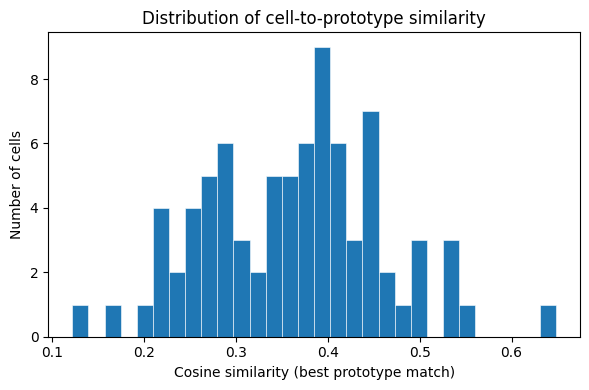

In [9]:
# distribution of best similarity scores
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(results["best_similarity"], bins=30, edgecolor="white", linewidth=0.4)
ax.set_xlabel("Cosine similarity (best prototype match)")
ax.set_ylabel("Number of cells")
ax.set_title("Distribution of cell-to-prototype similarity")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/similarity_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

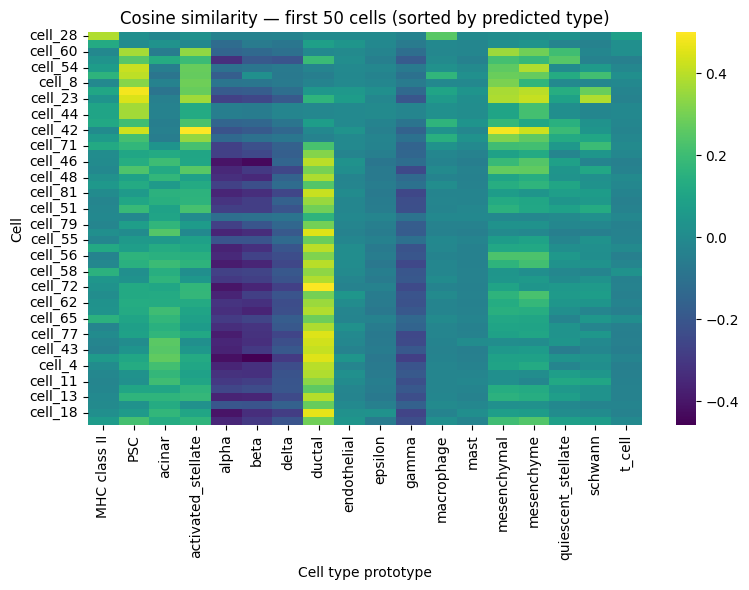

In [10]:
# heatmap — cells sorted by predicted type so structure is visible
sorted_idx = results.sort_values("predicted_cell_type").index
sim_subset = sim_df.loc[sorted_idx].iloc[:HEATMAP_N_CELLS]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(sim_subset, cmap="viridis", ax=ax)
ax.set_title(f"Cosine similarity — first {HEATMAP_N_CELLS} cells (sorted by predicted type)")
ax.set_xlabel("Cell type prototype")
ax.set_ylabel("Cell")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/similarity_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

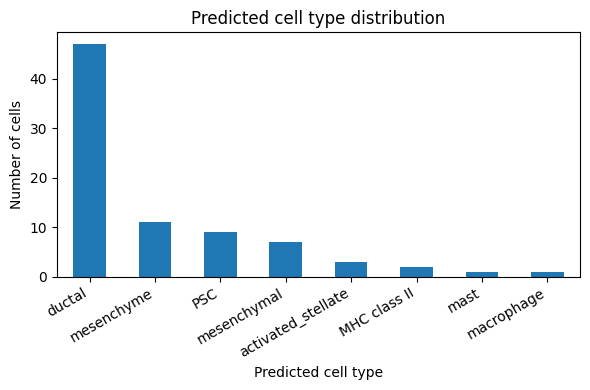

In [11]:
# bar chart of predicted cell type counts
counts = results["predicted_cell_type"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind="bar", ax=ax)
ax.set_xlabel("Predicted cell type")
ax.set_ylabel("Number of cells")
ax.set_title("Predicted cell type distribution")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/cell_type_counts.png", dpi=300, bbox_inches="tight")
plt.show()